# Sistem Rekomendasi Skill dan Analisis Tren Lowongan Kerja
**Coding Camp 2026 powered by DBS Foundation | CC26-PSU129**

Dataset: `Data_Scrapping_Raw.xlsx` - Scraping lowongan kerja IT dari LinkedIn Global

## Setup

In [1]:
# Instalasi library yang dibutuhkan selama proyek
!pip install pandas numpy matplotlib seaborn scikit-learn scipy openpyxl -q

---
# BAB 1: Problem Discovery & Pendahuluan
---

### 1.1 Latar Belakang Masalah

Perkembangan teknologi digital, khususnya di bidang *Artificial Intelligence* (AI) dan *Big Data*, sudah mengubah dunia kerja cukup drastis. Banyak pekerjaan lama perlahan tergantikan otomasi, sementara pekerjaan baru bermunculan dengan tuntutan skill yang berbeda-beda. Kondisi ini memaksa tenaga kerja untuk terus memperbarui kompetensi agar tidak tertinggal.

Masalahnya, banyak orang kesulitan menentukan skill apa yang sebaiknya dipelajari. Informasi lowongan kerja tersedia sangat banyak, tapi belum dimanfaatkan secara optimal untuk memberikan gambaran nyata tentang apa yang dibutuhkan industri. Di sinilah *skill gap* terjadi - jarak antara kompetensi yang dimiliki pencari kerja dengan apa yang sebenarnya diharapkan perusahaan.

Sistem rekomendasi selama ini lebih banyak dikenal di platform *e-commerce* atau hiburan. Belum banyak yang memanfaatkannya untuk pengembangan karier berbasis data pasar kerja nyata. Padahal dengan metode *deep learning*, data lowongan kerja bisa dianalisis untuk menemukan pola kebutuhan skill dan menghasilkan rekomendasi yang lebih tepat sasaran.

Proyek ini hadir untuk menjawab kebutuhan tersebut dan menjadi sistem yang bisa menganalisis tren lowongan secara otomatis, mengidentifikasi skill yang dibutuhkan, dan memberikan rekomendasi yang relevan agar pencari kerja bisa merencanakan pengembangan diri secara lebih terarah.


### 1.2 Solusi Utama

Proyek ini membangun sistem rekomendasi skill berbasis *deep learning* yang memanfaatkan data lowongan kerja IT dari LinkedIn Global. Sistem ini terdiri dari tiga komponen utama:

1. **Pipeline data**: scraping, cleaning, dan transformasi data lowongan menjadi dataset terstruktur yang siap dianalisis dan dilatih
2. **Model BiLSTM + Attention**: model *deep learning* yang mempelajari hubungan antara nama pekerjaan dan skill yang dibutuhkan, kemudian memberikan rekomendasi skill yang relevan
3. **Dashboard interaktif**: antarmuka berbasis Streamlit yang memungkinkan pengguna memasukkan nama pekerjaan dan mendapatkan rekomendasi skill beserta *career roadmap* yang dihasilkan oleh model generatif Groq/LLaMA

Keunggulan pendekatan ini dibanding sistem statis adalah kemampuannya menangkap pola kompleks dari ribuan lowongan kerja nyata, bukan sekadar mengandalkan daftar skill yang dikurasi secara manual.


### 1.3 Pertanyaan Bisnis

Berdasarkan latar belakang dan dataset yang telah diperoleh, dibuat 6 pertanyaan bisnis yang relevan dengan proyek ini. Masing-masing pertanyaan disusun mengikuti kriteria SMART agar dapat dijawab secara terukur dan terarah.

---

**BQ 1: Apa 30 skill yang paling banyak diminta berdasarkan dataset lowongan IT LinkedIn yang dikumpulkan?**

- **Specific:** Berfokus pada frekuensi kemunculan skill teknis di seluruh lowongan IT dalam dataset
- **Measurable:** Diukur menggunakan jumlah kemunculan setiap skill token dan persentasenya terhadap total lowongan
- **Achievable:** Dapat dijawab langsung dari kolom `skills_list` yang telah dibangun pada tahap cleaning
- **Relevant:** Menjawab kebutuhan pengguna sistem maupun pencari kerja dalam mengetahui skill apa yang harus diprioritaskan agar kompetitif di pasar kerja IT global
- **Time-bound:** Dibatasi pada dataset yang dikumpulkan (Mei - Juni 2026)

---

**BQ 2: Bagaimana persentase distribusi work type (Remote, Hybrid, On-site) pada 20 kategori pekerjaan IT dengan volume lowongan tertinggi berdasarkan dataset yang dikumpulkan?**

- **Specific:** Berfokus pada pola sebaran tipe kerja per kategori pekerjaan, dibatasi pada 20 kategori dengan volume tertinggi
- **Measurable:** Diukur menggunakan persentase proporsi masing-masing work type per kategori pekerjaan
- **Achievable:** Dapat dijawab dari kolom `work_type` dan `keyword` yang tersedia di dataset
- **Relevant:** Membantu pencari kerja yang memiliki preferensi kerja remote atau on-site dalam memilih jalur karier yang sesuai dengan gaya hidup mereka
- **Time-bound:** Dibatasi pada dataset yang dikumpulkan (Mei - Juni 2026)

---

**BQ 3: Kategori pekerjaan IT mana yang memiliki rata-rata jumlah skill tertinggi per lowongan berdasarkan dataset yang dikumpulkan?**

- **Specific:** Berfokus pada perbandingan kompleksitas skill antar kategori pekerjaan IT
- **Measurable:** Diukur menggunakan rata-rata kolom `n_skills` per kategori pekerjaan
- **Achievable:** Dapat dijawab langsung dari kolom `n_skills` dan `keyword` yang tersedia
- **Relevant:** Membantu pencari kerja memperkirakan seberapa besar investasi waktu dan energi yang dibutuhkan sebelum melamar ke jalur karier tertentu
- **Time-bound:** Dibatasi pada dataset yang dikumpulkan (Mei - Juni 2026)

---

**BQ: Skill apa yang memiliki distinctiveness ratio tertinggi pada masing-masing kategori pekerjaan IT berdasarkan dataset yang dikumpulkan?**

- **Specific:** Berfokus pada skill yang paling eksklusif dan membedakan satu kategori pekerjaan dari kategori lainnya
- **Measurable:** Diukur menggunakan distinctiveness ratio, yaitu perbandingan antara tingkat kemunculan skill di pekerjaan tertentu dengan tingkat kemunculannya secara global
- **Achievable:** Dapat dihitung dari kolom `skills_list` dan `keyword` yang tersedia di dataset
- **Relevant:** Membantu pencari kerja untuk fokus mempelajari skill yang benar-benar membedakan mereka di posisi yang dituju, bukan hanya skill generik yang semua orang miliki
- **Time-bound:** Dibatasi pada dataset yang dikumpulkan (Mei - Juni 2026)

---

**BQ 5: Apakah rata-rata jumlah skill lowongan Remote secara statistik lebih tinggi dibanding On-site berdasarkan dataset yang dikumpulkan?**

- **Specific:** Berfokus pada perbandingan tuntutan skill antara dua tipe kerja yang paling umum, yaitu Remote dan On-site
- **Measurable:** Diukur menggunakan rata-rata `n_skills` per tipe kerja dan divalidasi melalui independent samples t-test dengan α = 0.05
- **Achievable:** Dapat dijawab dari kolom `n_skills` dan `work_type` yang tersedia di dataset
- **Relevant:** Membantu pencari kerja yang ingin bekerja secara remote untuk memahami bahwa mereka perlu mempersiapkan skill yang lebih banyak dan lebih spesifik dibanding posisi on-site
- **Time-bound:** Dibatasi pada dataset yang dikumpulkan (Mei - Juni 2026)

---

**BQ 6: Apa 20 pasangan skill dengan nilai co-occurrence tertinggi berdasarkan dataset lowongan IT LinkedIn yang dikumpulkan?**

- **Specific:** Berfokus pada pola kemunculan bersama antar skill dalam satu lowongan, dibatasi pada 20 pasangan teratas
- **Measurable:** Diukur menggunakan nilai co-occurrence, yaitu jumlah lowongan di mana dua skill muncul secara bersamaan
- **Achievable:** Dapat dihitung dari kolom `skills_list` menggunakan pendekatan combinatorial pair counting
- **Relevant:** Membantu pencari kerja menyusun roadmap belajar yang efisien dengan mempelajari skill dalam satu klaster secara berurutan, bukan secara acak
- **Time-bound:** Dibatasi pada dataset yang dikumpulkan (Mei - Juni 2026)

---
# BAB 2: Data Wrangling & Persiapan Data
---

### Import Library

In [2]:
# Import library yang dipakai di seluruh notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Konfigurasi dasar plot supaya tampilannya bersih dan konsisten
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# Warna yang sama dengan dashboard Streamlit supaya visualisasi konsisten
PURPLE      = '#7C3AED'
PURPLE_DARK = '#5B21B6'
PURPLE_MID  = '#A78BFA'
PURPLE_LITE = '#EDE9FE'
GREY        = '#94A3B8'
TEXT_MUTED  = '#64748B'

print('Library siap.')


Library siap.


### 2.1 Data Gathering

Dataset diperoleh dari proses *web scraping* mandiri menggunakan Python dari platform LinkedIn, dengan 105 keyword pekerjaan IT sebagai kata kunci pencarian. Hasil scraping disimpan dalam format `.xlsx`.

| Atribut | Keterangan |
|---|---|
| Sumber | LinkedIn Global (scraping mandiri) |
| Format | `.xlsx` |
| Keyword | 105 pekerjaan IT |


In [3]:
# Baca file Excel hasil scraping
df_raw = pd.read_excel('Data_Scrapping_Raw (2).xlsx')

# Cek dimensi dan struktur awal dataset
print(f'Jumlah baris  : {len(df_raw):,}')
print(f'Jumlah kolom  : {df_raw.shape[1]}')
print(f'Nama kolom    : {df_raw.columns.tolist()}')
print()
print(f'Keyword unik  : {df_raw["keyword"].nunique()}')
print(f'Job title unik: {df_raw["job_title"].nunique():,}')
print(f'Company unik  : {df_raw["company"].nunique():,}')
print()
display(df_raw[['keyword','job_title','company','location','skills']].head())


Jumlah baris  : 4,542
Jumlah kolom  : 9
Nama kolom    : ['keyword', 'job_title', 'company', 'location', 'work_type', 'salary', 'skills', 'job_url', 'description']

Keyword unik  : 105
Job title unik: 2,432
Company unik  : 2,892



,keyword,job_title,company,location,skills
0,"""Back End Developer""",Back-end Developer,Keyvoto,Yunani (Jarak Jauh),"C, C#, CSS3, HTML5, Python, SQL"
1,"""Back End Developer""",Java Back-End Developer with Banking Experience,Müller's Solutions,"Riyadh, Riyadh, Arab Saudi (Di Kantor)","Docker, Git, GitLab, Hibernate, Java, Jenkins,..."
2,"""Back End Developer""",Back End Developer,RXPERT ADVISORS PRIVATE LIMITED,"Delhi, India (Di Kantor)","C, C++, Foundation, GitHub, Java, Netlify, Vercel"
3,"""Back End Developer""",Back End Developer with verification,Digital Waffle,Spanyol (Jarak Jauh),"Docker, Git, GitLab, Google Cloud Platform (GC..."
4,"""Back End Developer""",Junior Back-End Developer,Analyticsmart,"Toronto, ON (Di Kantor)","Angular, Computer Vision, Docker, Git, JavaScr..."


### 2.2 Data Assessing

Sebelum cleaning, data mentah diperiksa dulu secara menyeluruh untuk tahu masalah apa saja yang perlu ditangani.


In [4]:
# Cek missing value di tiap kolom
print('Missing Values per Kolom:')
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
df_missing  = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
print(df_missing[df_missing['Count'] > 0].to_string())
print()

# Cek tipe data tiap kolom
print('Tipe Data:')
print(df_raw.dtypes.to_string())
print()

# Cek duplikat dari tiga sudut: baris penuh, URL, dan kombinasi title + skill + company
dup_full = df_raw.duplicated().sum()
dup_url  = df_raw['job_url'].duplicated().sum()
dup_tsc  = df_raw[['job_title','skills','company']].duplicated().sum()
print(f'Duplikat baris penuh          : {dup_full}')
print(f'Duplikat URL                  : {dup_url}')
print(f'Duplikat title + skill + co.  : {dup_tsc}  <- akan di-drop')
print()
print('Catatan:')
print('  work_type  - 100% kosong, info tipe kerja tersimpan di kolom location')
print('  salary     - 100% kosong, tidak digunakan')
print('  keyword    - Inconsistent Formatting: ada tanda kutip ganda yang perlu dibersihkan')
print(f'  Contoh    : {df_raw["keyword"].unique()[:3].tolist()}')


Missing Values per Kolom:
             Count  Pct (%)
company          6     0.13
work_type     4542   100.00
salary        4542   100.00
skills         594    13.08
description      5     0.11

Tipe Data:
keyword         object
job_title       object
company         object
location        object
work_type      float64
salary         float64
skills          object
job_url         object
description     object

Duplikat baris penuh          : 0
Duplikat URL                  : 8
Duplikat title + skill + co.  : 548  <- akan di-drop

Catatan:
  work_type  - 100% kosong, info tipe kerja tersimpan di kolom location
  salary     - 100% kosong, tidak digunakan
  keyword    - Inconsistent Formatting: ada tanda kutip ganda yang perlu dibersihkan
  Contoh    : ['"Back End Developer"', '"Front End Developer"', '"FullStack Developer"']


**Temuan Assessing:**

Dua kolom kosong sepenuhnya teridentifikasi, yaitu `work_type` dan `salary`. Kolom `work_type` tidak perlu langsung di-drop karena informasi tipe kerja sebenarnya sudah ada di kolom `location`, tersimpan dalam format seperti *'Jakarta, Indonesia (Jarak Jauh)'* dan akan diekstrak saat cleaning. Sedangkan `salary` memang tidak tersedia dan tidak akan digunakan sama sekali. Duplikat sebanyak 548 baris pada kombinasi `title+skill+company` adalah posting yang benar-benar identik dan akan dibuang.


### 2.3 Data Cleaning

Dari `df_raw` dibuat salinan `df_eda` dengan langkah-langkah cleaning berikut:
- Tanda kutip ganda pada kolom `keyword` dihapus
- `work_type` diekstrak dari kolom `location` menggunakan pencocokan kata kunci bahasa Indonesia
- `location_fix` diekstrak dari bagian akhir kolom `location` sebagai nama wilayah
- Kolom `skills` di-parse dari format string menjadi list
- Duplikat berdasarkan kombinasi `title + skill + company` di-drop


In [5]:
# Ekstrak work type dari kolom location pakai kata kunci bahasa Indonesia
def extract_work_type(loc):
    if not isinstance(loc, str): return 'Tidak Diketahui'
    if 'Jarak Jauh' in loc: return 'Remote'
    if 'Di Kantor'  in loc: return 'On-site'
    if 'Gabungan'   in loc: return 'Hybrid'
    return 'Tidak Diketahui'

# Ekstrak nama wilayah dari bagian akhir kolom location
def extract_location_fix(loc):
    if not isinstance(loc, str): return 'Unknown'
    clean = re.sub(r'\(.*?\)', '', loc).strip()
    parts = [p.strip() for p in clean.split(',')]
    return parts[-1].strip() if parts else 'Unknown'

# Salin df_raw ke df_eda supaya data asli tidak berubah
df_eda = df_raw.copy()

# Bersihkan tanda kutip ganda di kolom keyword
df_eda['keyword']      = df_eda['keyword'].str.replace('"', '').str.strip()

# Tambah kolom work_type dan location_fix dari kolom location
df_eda['work_type']    = df_eda['location'].apply(extract_work_type)
df_eda['location_fix'] = df_eda['location'].apply(extract_location_fix)

# Parse kolom skills dari string ke list, sekalian hitung jumlah skill per baris
df_eda['skills_list'] = df_eda['skills'].apply(
    lambda x: [s.strip().lower() for s in str(x).split(',') if s.strip() and len(s.strip()) > 1]
    if pd.notna(x) else []
)
df_eda['n_skills'] = df_eda['skills_list'].apply(len)

# Buang duplikat berdasarkan kombinasi title + skill + company
before = len(df_eda)
df_eda = df_eda.drop_duplicates(subset=['job_title','skills','company'], keep='first')
print(f'df_raw -> df_eda: {before:,} -> {len(df_eda):,} baris')
print(f'Duplikat dibuang : {before - len(df_eda)}')
print()

# Bangun frekuensi global semua skill token, akan dipakai di analisis berikutnya
all_skills_flat = [s for row in df_eda['skills_list'] for s in row]
skill_freq      = Counter(all_skills_flat)
print(f'Unique skill tokens : {len(set(all_skills_flat)):,}')
print(f'Total skill tokens  : {len(all_skills_flat):,}')
print()
print('Work type hasil ekstraksi:')
print(df_eda['work_type'].value_counts().to_string())


df_raw -> df_eda: 4,542 -> 3,994 baris
Duplikat dibuang : 548

Unique skill tokens : 428
Total skill tokens  : 16,870

Work type hasil ekstraksi:
work_type
On-site    1524
Hybrid     1243
Remote     1227


**Hasil Cleaning:**

Setelah cleaning, `df_eda` punya empat kolom tambahan yaitu `work_type`, `location_fix`, `skills_list`, dan `n_skills` yang akan dipakai di seluruh analisis EDA. Baris yang di-drop adalah posting yang benar-benar identik, bukan lowongan berbeda dari perusahaan yang sama, jadi penghapusan ini tidak menghilangkan informasi yang bermakna.


### 2.4 Data Dictionary

Berikut adalah metadata dari dataset `df_eda` yang telah bersih dan siap dianalisis:

In [6]:
# Buat tabel metadata kolom df_eda yang sudah bersih
dd = pd.DataFrame([
    ('keyword',     'string',       'Kata kunci pekerjaan yang digunakan saat scraping LinkedIn',
     'Data Scientist, Back End Developer', '105 nilai unik'),
    ('job_title',   'string',       'Judul pekerjaan asli dari posting LinkedIn',
     'Senior Data Scientist at Google',    'sangat beragam'),
    ('company',     'string',       'Nama perusahaan pemasang lowongan',
     'Google, Tokopedia',                  'beberapa null'),
    ('location',    'string',       'Lokasi dan tipe kerja dalam satu kolom',
     'Jakarta, Indonesia (Jarak Jauh)',    ''),
    ('work_type',   'string',       'Tipe kerja hasil ekstraksi dari kolom location',
     'Remote / On-site / Hybrid',          'hasil cleaning'),
    ('location_fix','string',       'Wilayah hasil ekstraksi dari kolom location',
     'Indonesia, India, United Kingdom',   'hasil cleaning'),
    ('skills_list', 'list[string]', 'Skill teknis hasil parsing dari kolom skills',
     "['python', 'sql', 'docker']",         'hasil cleaning'),
    ('n_skills',    'integer',      'Jumlah skill yang tercantum per lowongan',
     '7',                                  'hasil cleaning'),
    ('skills',      'string',       'Skill teknis dalam format string asli',
     'Python, SQL, Docker',                'kolom asli'),
    ('job_url',     'string',       'URL posting lowongan di LinkedIn',
     'https://linkedin.com/...',           'unique identifier'),
], columns=['Kolom','Tipe','Deskripsi','Contoh Nilai','Catatan'])

# Tampilkan dengan styling tabel yang rapi
display(dd.style
    .set_properties(**{'text-align':'left','font-size':'12px','padding':'5px 10px'})
    .set_table_styles([{'selector':'th',
                        'props':[('background-color','#7C3AED'),('color','white')]}]))


,Kolom,Tipe,Deskripsi,Contoh Nilai,Catatan
0,keyword,string,Kata kunci pekerjaan yang digunakan saat scraping LinkedIn,"Data Scientist, Back End Developer",105 nilai unik
1,job_title,string,Judul pekerjaan asli dari posting LinkedIn,Senior Data Scientist at Google,sangat beragam
2,company,string,Nama perusahaan pemasang lowongan,"Google, Tokopedia",beberapa null
3,location,string,Lokasi dan tipe kerja dalam satu kolom,"Jakarta, Indonesia (Jarak Jauh)",
4,work_type,string,Tipe kerja hasil ekstraksi dari kolom location,Remote / On-site / Hybrid,hasil cleaning
5,location_fix,string,Wilayah hasil ekstraksi dari kolom location,"Indonesia, India, United Kingdom",hasil cleaning
6,skills_list,list[string],Skill teknis hasil parsing dari kolom skills,"['python', 'sql', 'docker']",hasil cleaning
7,n_skills,integer,Jumlah skill yang tercantum per lowongan,7,hasil cleaning
8,skills,string,Skill teknis dalam format string asli,"Python, SQL, Docker",kolom asli
9,job_url,string,URL posting lowongan di LinkedIn,https://linkedin.com/...,unique identifier


Simpan `df_eda` ke file CSV untuk nantinya input data untuk **dashboard EDA** (`eda_dashboard.py`) yang menampilkan seluruh visualisasi dan jawaban pertanyaan bisnis secara interaktif

In [7]:
df_eda.to_csv('df_eda_fix.csv', index=False)
print(f'df_eda_fix.csv tersimpan -- {len(df_eda):,} baris')

df_eda_fix.csv tersimpan -- 3,994 baris


---
# BAB 3: Exploratory Data Analysis (EDA) & Explanatory Analysis
---

### 3.1 Exploratory Data Analysis - Gambaran Umum Dataset

Sebelum masuk ke pertanyaan bisnis, dilakukan eksplorasi umum dulu untuk memahami distribusi data secara keseluruhan.


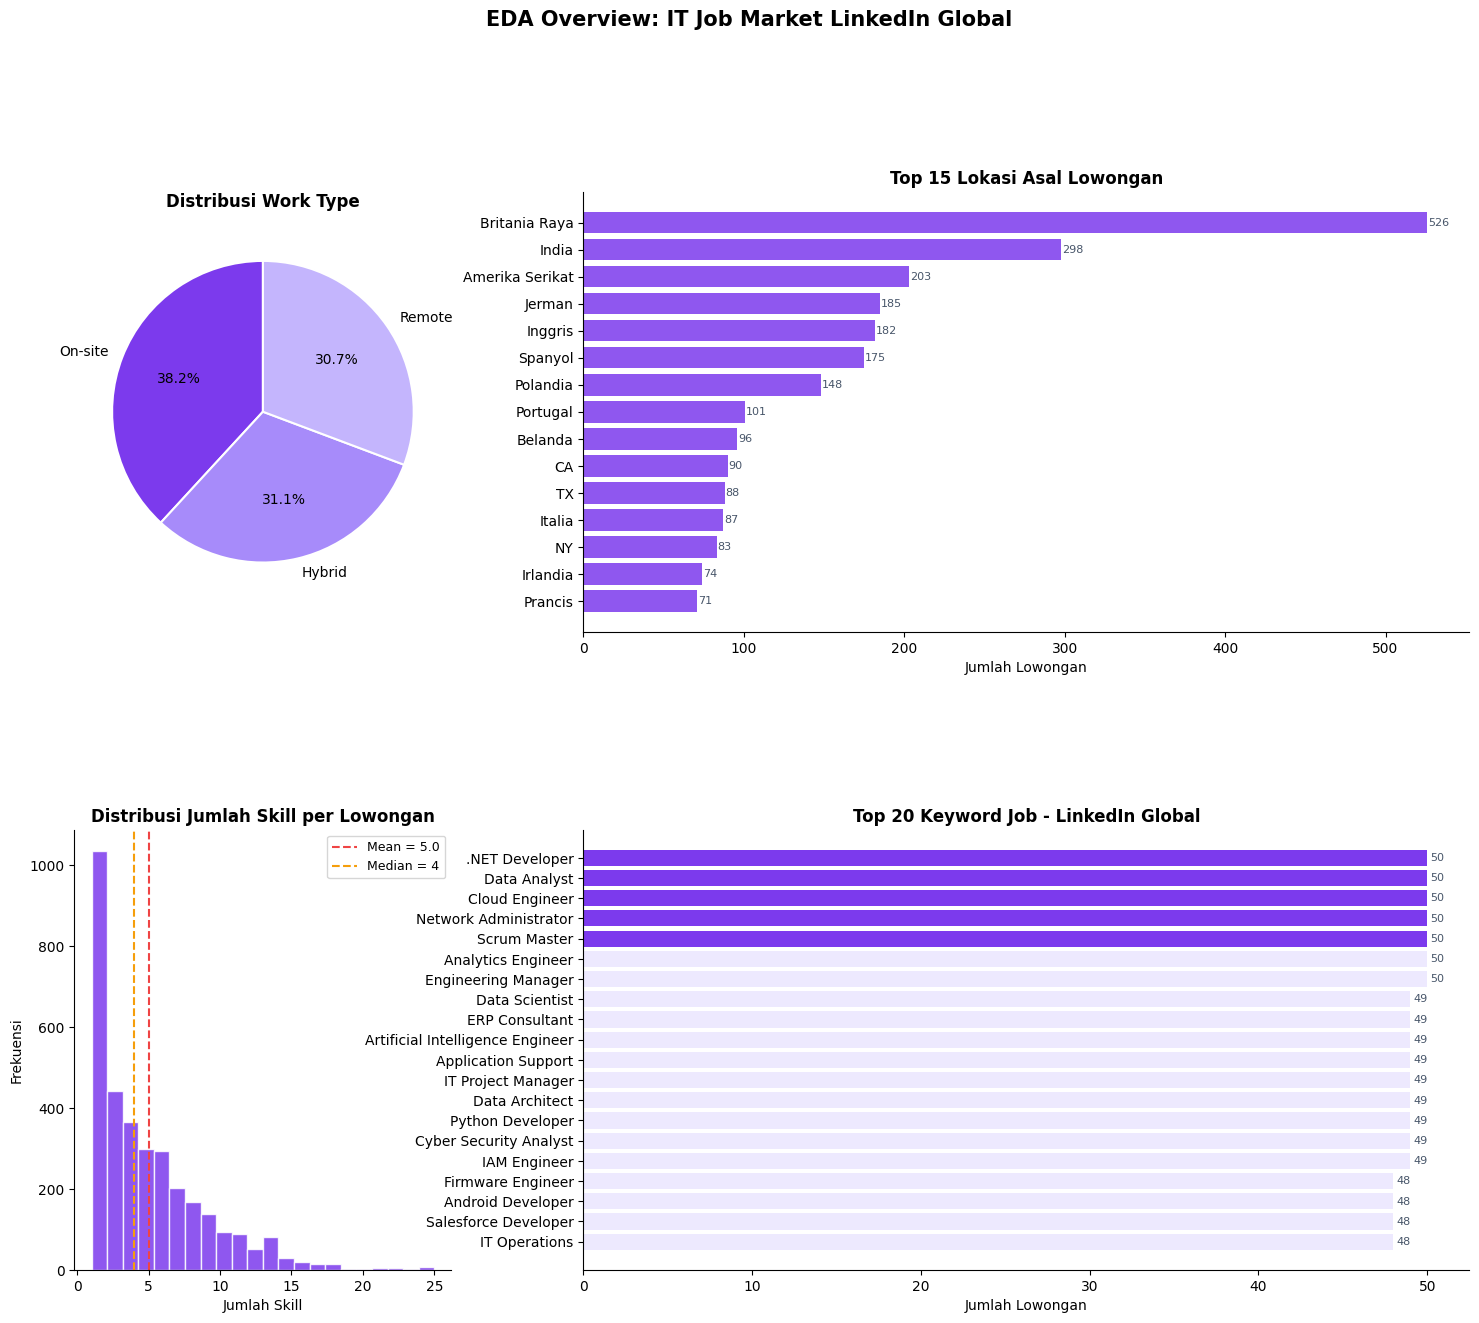

Tersimpan: eda_overview.png


In [8]:
# Canvas 2x3 untuk empat visualisasi ringkasan dataset
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Pie chart distribusi work type
ax1 = fig.add_subplot(gs[0, 0])
wt  = df_eda['work_type'].value_counts()
colors_pie = [PURPLE, '#A78BFA', '#C4B5FD', '#DDD6FE']
ax1.pie(wt.values, labels=wt.index, autopct='%1.1f%%',
        colors=colors_pie[:len(wt)], startangle=90,
        wedgeprops={'linewidth':1.5,'edgecolor':'white'})
ax1.set_title('Distribusi Work Type', fontweight='bold', pad=12)

# Top 15 lokasi asal lowongan
ax2 = fig.add_subplot(gs[0, 1:])
top_countries = df_eda['location_fix'].value_counts().head(15)
bars = ax2.barh(top_countries.index[::-1], top_countries.values[::-1],
                color=PURPLE, alpha=0.85)
ax2.set_title('Top 15 Lokasi Asal Lowongan', fontweight='bold')
ax2.set_xlabel('Jumlah Lowongan')
for bar, val in zip(bars, top_countries.values[::-1]):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8, color='#475569')

# Histogram jumlah skill per lowongan, tambahkan garis mean dan median
ax3 = fig.add_subplot(gs[1, 0])
data_hist = df_eda[df_eda['n_skills'] > 0]['n_skills']
ax3.hist(data_hist, bins=22, color=PURPLE, edgecolor='white', alpha=0.85)
ax3.axvline(data_hist.mean(),   color='#EF4444', linestyle='--', linewidth=1.5,
            label=f'Mean = {data_hist.mean():.1f}')
ax3.axvline(data_hist.median(), color='#F59E0B', linestyle='--', linewidth=1.5,
            label=f'Median = {data_hist.median():.0f}')
ax3.set_title('Distribusi Jumlah Skill per Lowongan', fontweight='bold')
ax3.set_xlabel('Jumlah Skill')
ax3.set_ylabel('Frekuensi')
ax3.legend(fontsize=9)

# Top 20 keyword dengan jumlah lowongan terbanyak
ax4 = fig.add_subplot(gs[1, 1:])
kw_counts = df_eda['keyword'].value_counts().head(20)
clr_kw    = [PURPLE if i < 5 else PURPLE_LITE for i in range(20)]
bars4 = ax4.barh(kw_counts.index[::-1], kw_counts.values[::-1], color=clr_kw[::-1])
ax4.set_title('Top 20 Keyword Job - LinkedIn Global', fontweight='bold')
ax4.set_xlabel('Jumlah Lowongan')
for bar, val in zip(bars4, kw_counts.values[::-1]):
    ax4.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=8, color='#475569')

fig.suptitle('EDA Overview: IT Job Market LinkedIn Global', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: eda_overview.png')


**Temuan EDA Umum:**

Dataset mencakup lowongan dari lebih dari 15 lokasi, dengan dominasi dari Britania Raya, India, dan Amerika Serikat. Distribusi tipe kerja menunjukkan Remote dan On-site cukup seimbang. Distribusi jumlah skill per lowongan bersifat *right-skewed* - mayoritas lowongan mencantumkan 1 sampai 8 skill, tapi ada juga yang mencapai lebih dari 20 skill. Keyword Data Scientist dan Data Analyst mendominasi volume lowongan di dataset ini.


### 3.2 Explanatory Analysis - Jawaban atas Pertanyaan Bisnis

Bagian ini menyajikan visualisasi dan analisis yang secara langsung menjawab setiap pertanyaan bisnis yang sudah dirumuskan di Bab 1. Keenam pertanyaan dijawab secara berurutan dan saling berkaitan, membentuk satu alur analisis yang utuh tentang pasar kerja IT global.

Dimulai dari BQ 1 yang memetakan lanskap skill secara keseluruhan, BQ 2 yang melihat pola work type per kategori pekerjaan, BQ 3 yang mengukur kompleksitas skill tiap pekerjaanan, BQ 4 yang menggali skill khas per kategori, BQ 5 yang membandingkan tuntutan skill antara remote dan on-site, hingga BQ 6 yang melihat pola kombinasi skill yang paling sering muncul bersama.


#### BQ 1: Skill teknis apa yang paling tinggi frekuensi permintaannya di industri IT secara global?

Mengukur kemunculan setiap skill di seluruh 3.994 lowongan yang tersedia setelah cleaning.


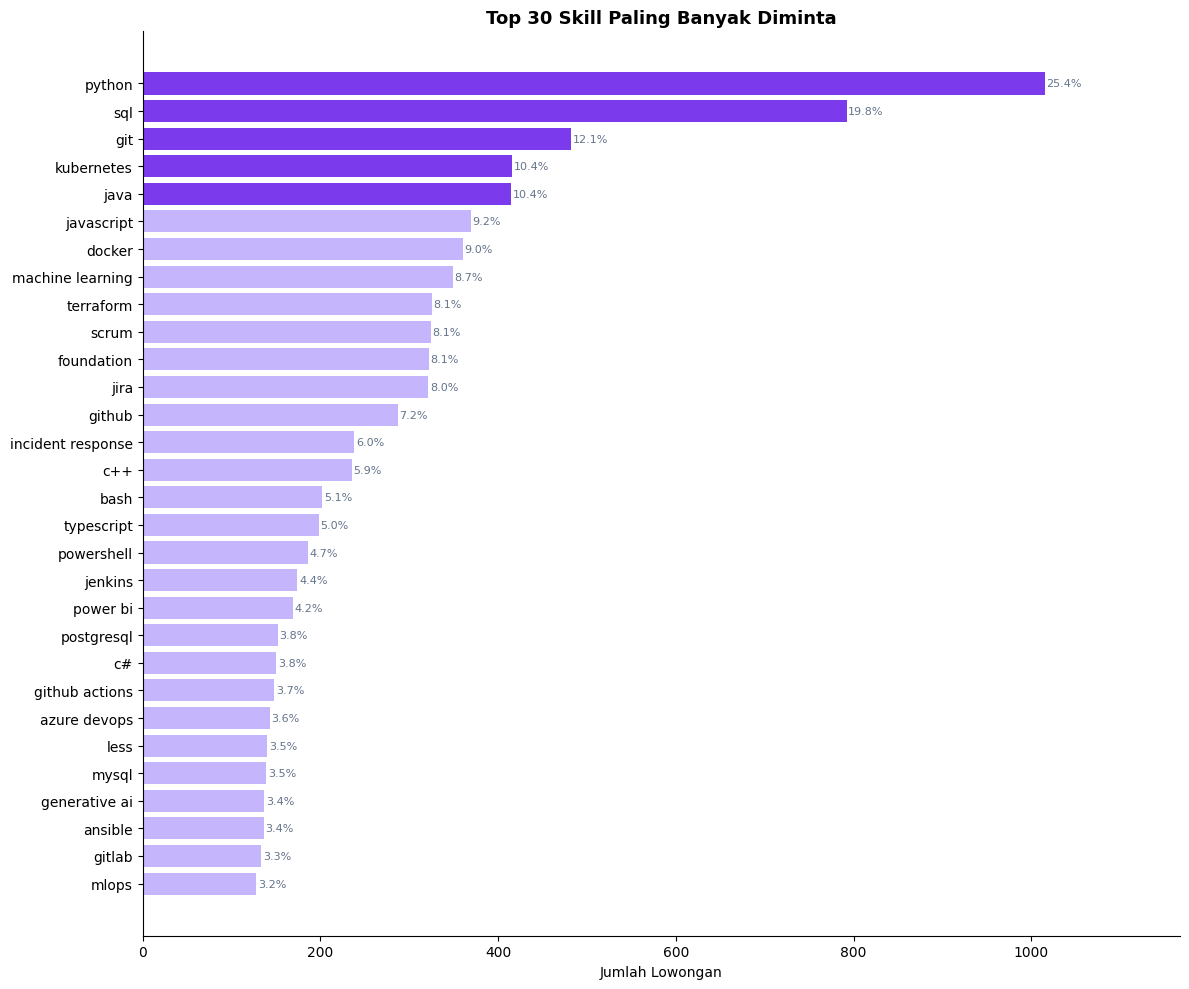

Tersimpan: bq1_top_skills.png

Top 10 skill global:
   1. python                     1015 lowongan (25.4%) ######################################
   2. sql                         792 lowongan (19.8%) #############################
   3. git                         482 lowongan (12.1%) ##################
   4. kubernetes                  416 lowongan (10.4%) ###############
   5. java                        414 lowongan (10.4%) ###############
   6. javascript                  369 lowongan (9.2%) #############
   7. docker                      360 lowongan (9.0%) #############
   8. machine learning            349 lowongan (8.7%) #############
   9. terraform                   325 lowongan (8.1%) ############
  10. scrum                       324 lowongan (8.1%) ############


In [9]:
# Ambil 30 skill teratas dan hitung persentase kemunculannya
top30 = pd.DataFrame(skill_freq.most_common(30), columns=['skill','count'])
top30['pct'] = (top30['count'] / len(df_eda) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 10))

# Top 5 warna lebih gelap, sisanya lebih terang
colors_bq1 = [PURPLE if i < 5 else '#C4B5FD' for i in range(30)]
bars = ax.barh(top30['skill'][::-1], top30['count'][::-1], color=colors_bq1[::-1])
ax.set_title('Top 30 Skill Paling Banyak Diminta', fontweight='bold', fontsize=13)
ax.set_xlabel('Jumlah Lowongan')

# Tambahkan label persentase di luar bar
for i, (cnt, pct) in enumerate(zip(top30['count'][::-1], top30['pct'][::-1])):
    ax.text(cnt + 2, i, f'{pct}%', va='center', fontsize=8, color=TEXT_MUTED)

ax.set_xlim(0, top30['count'].max() * 1.15)
plt.tight_layout()
plt.savefig('bq1_top_skills.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: bq1_top_skills.png')
print()
print('Top 10 skill global:')
for rank, (sk, cnt) in enumerate(skill_freq.most_common(10), 1):
    pct = cnt / len(df_eda) * 100
    bar = '#' * int(pct * 1.5)
    print(f'  {rank:2d}. {sk:25s} {cnt:5d} lowongan ({pct:.1f}%) {bar}')


**Jawaban BQ 1:**

Python mendominasi dengan kemunculan di lebih dari 1.000 lowongan, sekitar 25% dari seluruh dataset. Skill ini sudah bukan sekadar nilai tambah, tapi sudah jadi prasyarat dasar di hampir semua kategori pekerjaan IT.

Lima skill teratas mencerminkan dua klaster besar: klaster *data pipeline* (Python, SQL) dan klaster *cloud infrastructure* (Kubernetes, Docker, Terraform). Industri IT global saat ini tidak hanya butuh orang yang bisa coding, tapi juga yang paham cara mengelola data dan infrastruktur cloud sekaligus. Git yang ada di posisi atas juga sudah jadi *hygiene factor* - hampir selalu disyaratkan tanpa memandang kategori pekerjaan.


#### BQ 2: Bagaimana sebaran tipe pekerjaan (remote, hybrid, on-site) di setiap kategori pekerjaan IT?

Memetakan proporsi Remote, Hybrid, dan On-site untuk setiap kategori pekerjaan berdasarkan 20 keyword dengan volume lowongan tertinggi.


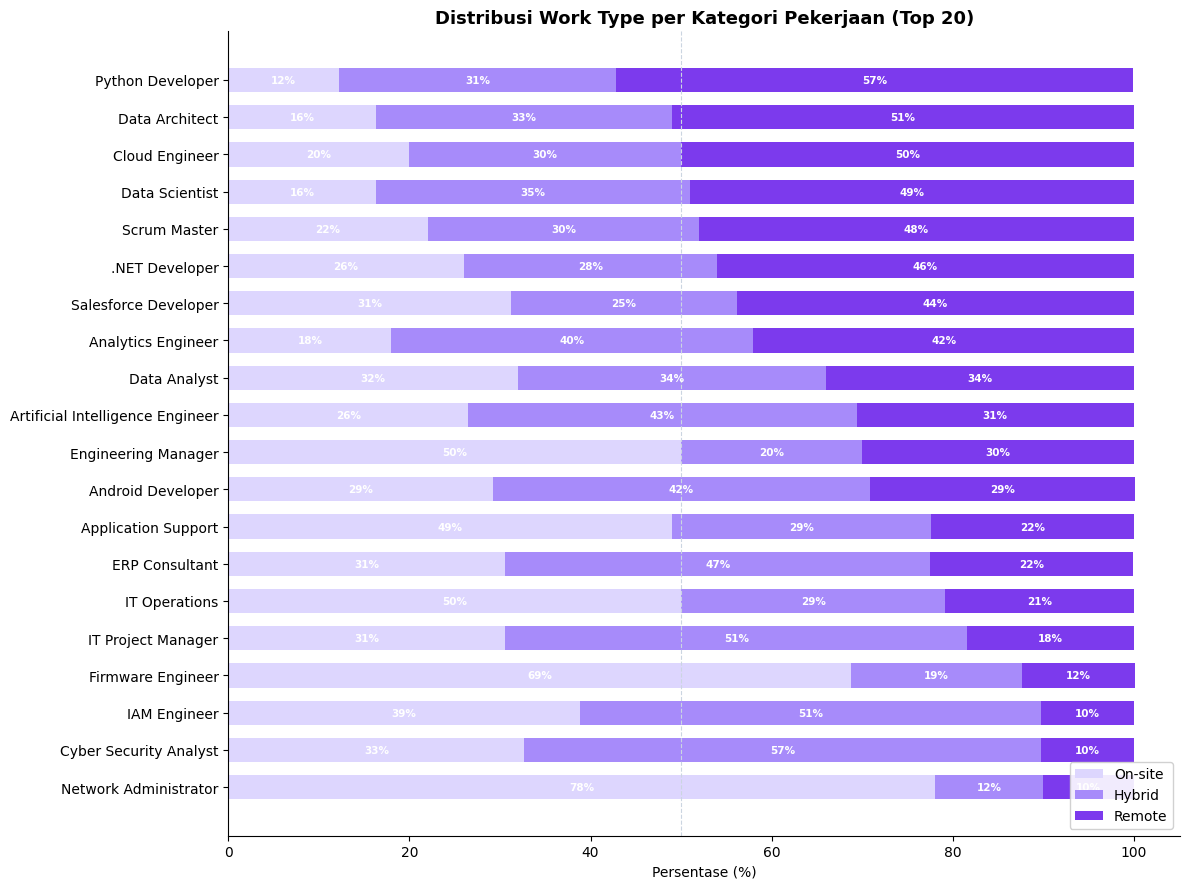

Tersimpan: bq2_worktype.png

Top 5 paling Remote-friendly:
  Python Developer                    57.1%
  Data Architect                      51.0%
  Cloud Engineer                      50.0%
  Data Scientist                      49.0%
  Scrum Master                        48.0%

Top 5 paling dominan On-site:
  Network Administrator               78.0%
  Firmware Engineer                   68.8%
  Engineering Manager                 50.0%
  IT Operations                       50.0%
  Application Support                 49.0%


In [10]:
# Filter ke 20 keyword dengan volume lowongan terbanyak
top20_kw = df_eda['keyword'].value_counts().head(20).index.tolist()
df_wt    = df_eda[df_eda['keyword'].isin(top20_kw)]

# Buat pivot table jumlah lowongan per kombinasi keyword dan work_type
wt_pivot = (
    df_wt.groupby(['keyword','work_type'])
    .size().unstack(fill_value=0)
    .reindex(columns=['Remote','Hybrid','On-site','Tidak Diketahui'], fill_value=0)
)
# Konversi ke persentase, buang kolom yang tidak relevan
wt_pct = wt_pivot.div(wt_pivot.sum(axis=1), axis=0).mul(100).round(1)
wt_pct = wt_pct.drop(columns=['Tidak Diketahui'], errors='ignore')
wt_pct = wt_pct.sort_values('Remote', ascending=True)

# Warna sesuai dashboard Streamlit
colors_wt = {'Remote': PURPLE, 'Hybrid': PURPLE_MID, 'On-site': '#DDD6FE'}

fig, ax = plt.subplots(figsize=(12, 9))

# Stacked bar chart, tiap segmen ditempel label persentasenya
bottom = np.zeros(len(wt_pct))
for wt in ['On-site','Hybrid','Remote']:
    if wt not in wt_pct.columns: continue
    vals = wt_pct[wt].values
    ax.barh(wt_pct.index, vals, left=bottom,
            color=colors_wt[wt], label=wt, height=0.65)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax.text(b + v/2, i, f'{v:.0f}%',
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='600')
    bottom += vals

ax.set_title('Distribusi Work Type per Kategori Pekerjaan (Top 20)', fontweight='bold', fontsize=13)
ax.set_xlabel('Persentase (%)')
ax.axvline(50, color='#CBD5E1', linestyle='--', linewidth=0.8)
ax.legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('bq2_worktype.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: bq2_worktype.png')
print()
top5_r = wt_pct['Remote'].sort_values(ascending=False).head(5) if 'Remote' in wt_pct else []
print('Top 5 paling Remote-friendly:')
for kw, pct in top5_r.items():
    print(f'  {kw:35s} {pct:.1f}%')
top5_o = wt_pct['On-site'].sort_values(ascending=False).head(5) if 'On-site' in wt_pct else []
print()
print('Top 5 paling dominan On-site:')
for kw, pct in top5_o.items():
    print(f'  {kw:35s} {pct:.1f}%')


**Jawaban BQ 2:**

Pola distribusi tipe kerja sangat berbeda antar kategori pekerjaan dan sejalan dengan sifat pekerjaannya masing-masing.

Pekerjaan yang sepenuhnya dilakukan via terminal dan dashboard cloud seperti DevOps Engineer dan Cloud Engineer wajar punya persentase remote tertinggi. Sebaliknya, pekerjaan IT Ops, Network Engineer, dan IT Support yang memerlukan akses fisik ke perangkat keras atau koordinasi langsung dengan pengguna non-teknis masih sangat didominasi tipe on-site.

Informasi ini berguna bagi pencari kerja yang memprioritaskan fleksibilitas lokasi kerja dalam menentukan jalur karier.


#### BQ 3: Kategori pekerjaan mana yang menuntut penguasaan skill paling beragam dari kandidatnya?

Membandingkan rata-rata jumlah skill yang dicantumkan per lowongan untuk setiap kategori pekerjaan, dilengkapi distribusi keseluruhan dataset.


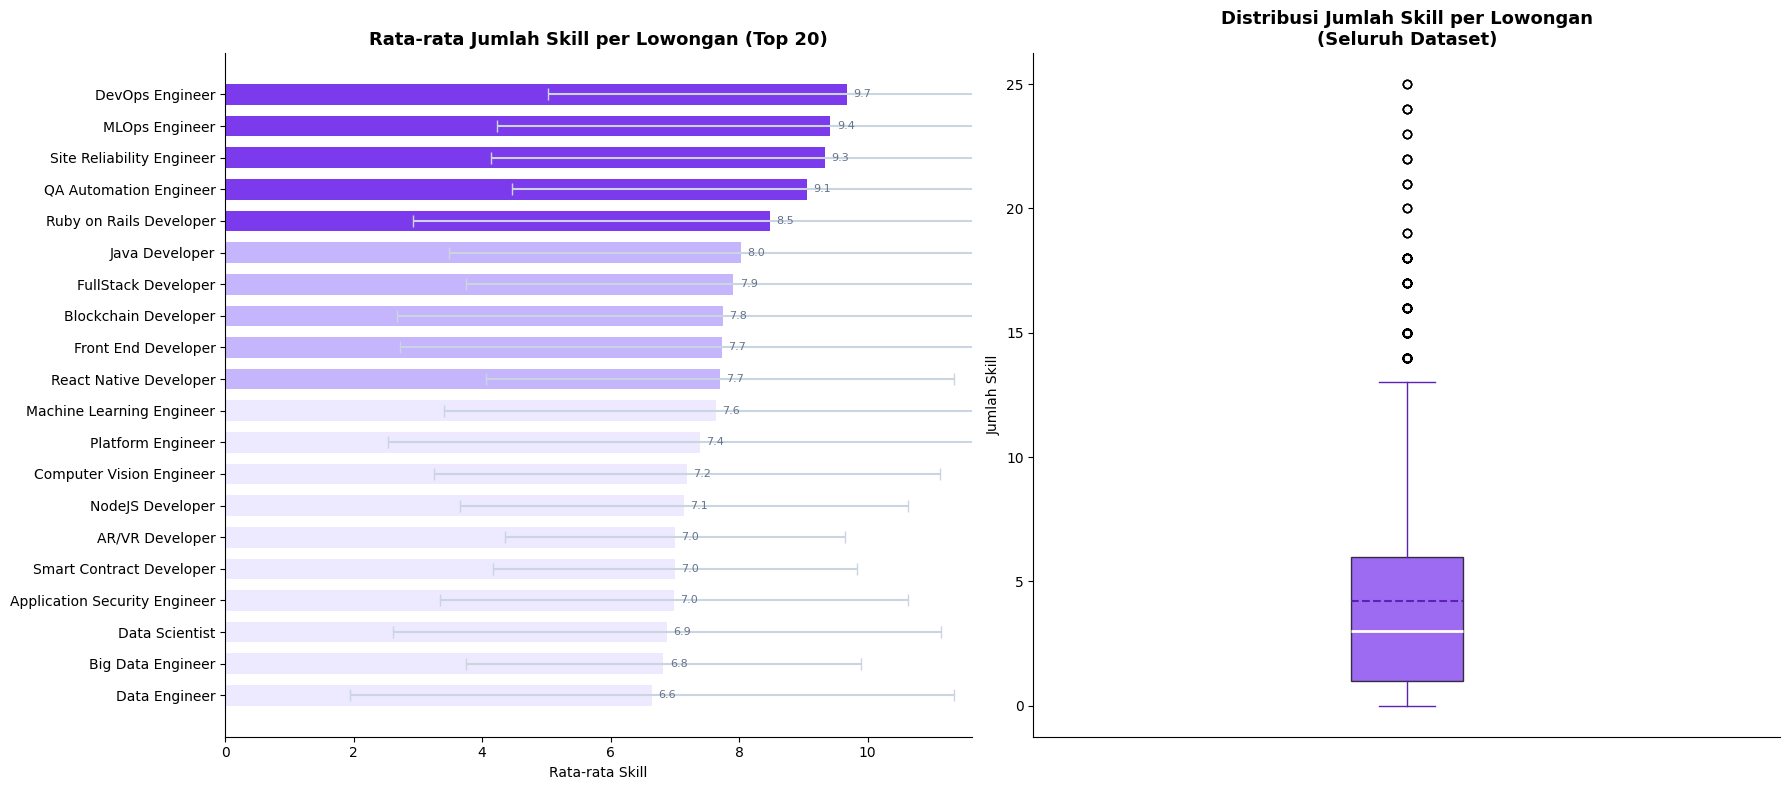

Tersimpan: bq3_complexity.png

Top 10 kategori rata-rata skill terbanyak:
                  keyword  rata_rata  std_dev  n_jobs
          DevOps Engineer       9.68     4.65      47
           MLOps Engineer       9.42     5.19      48
Site Reliability Engineer       9.33     5.20      48
   QA Automation Engineer       9.05     4.59      38
  Ruby on Rails Developer       8.48     5.56      27
           Java Developer       8.02     4.54      47
      FullStack Developer       7.91     4.16      43
     Blockchain Developer       7.75     5.07      12
      Front End Developer       7.73     5.01      48
   React Native Developer       7.70     3.64      43


In [11]:
# Hitung statistik deskriptif jumlah skill per keyword, urutkan dari tertinggi
complexity = (
    df_eda.groupby('keyword')['n_skills']
    .agg(['mean','median','std','count'])
    .round(2).reset_index()
    .rename(columns={'mean':'rata_rata','median':'median_val',
                     'std':'std_dev','count':'n_jobs'})
    .sort_values('rata_rata', ascending=False)
)

top20_c = complexity.head(20)
n_c     = len(top20_c)

# Gradasi warna: top 5 paling gelap, makin ke bawah makin terang
colors_c = [PURPLE if i < 5 else '#C4B5FD' if i < 10 else PURPLE_LITE for i in range(n_c)]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart rata-rata skill dengan error bar untuk menunjukkan sebaran
axes[0].barh(top20_c['keyword'][::-1], top20_c['rata_rata'][::-1],
             xerr=top20_c['std_dev'][::-1],
             color=colors_c[::-1],
             error_kw={'elinewidth':1.5,'ecolor':'#CBD5E1','capsize':4},
             height=0.65)
axes[0].set_title('Rata-rata Jumlah Skill per Lowongan (Top 20)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Rata-rata Skill')
axes[0].set_xlim(0, top20_c['rata_rata'].max() * 1.2)
for i, mean in enumerate(top20_c['rata_rata'][::-1]):
    axes[0].text(mean + 0.1, i, f'{mean:.1f}', va='center', fontsize=8, color=TEXT_MUTED)

# Box plot distribusi n_skills seluruh dataset
bp = axes[1].boxplot(df_eda['n_skills'].dropna(),
                     patch_artist=True,
                     medianprops={'color':'white','linewidth':2},
                     meanline=True, showmeans=True,
                     meanprops={'color':PURPLE_DARK,'linewidth':1.5,'linestyle':'--'})
bp['boxes'][0].set_facecolor(PURPLE)
bp['boxes'][0].set_alpha(0.75)
for element in ['whiskers','caps','fliers']:
    for item in bp[element]:
        item.set_color(PURPLE_DARK)
axes[1].set_title('Distribusi Jumlah Skill per Lowongan\n(Seluruh Dataset)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Jumlah Skill')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('bq3_complexity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: bq3_complexity.png')
print()
print('Top 10 kategori rata-rata skill terbanyak:')
print(complexity.head(10)[['keyword','rata_rata','std_dev','n_jobs']].to_string(index=False))


**Jawaban BQ 3:**

Pekerjaan DevOps dan Cloud secara konsisten ada di puncak dengan rata-rata 7 sampai 8 skill per lowongan. Wajar, karena peran ini menyentuh banyak layer teknologi sekaligus mulai dari sistem operasi, container orchestration, CI/CD pipeline, monitoring, hingga cloud provider.

Di sisi lain, pekerjaan IT Ops dan IT Support hanya mencantumkan 2 sampai 3 skill rata-rata. Bukan berarti lebih mudah, tapi deskripsi lowongannya memang cenderung kurang terperinci secara teknis.

Pencari kerja bisa pakai informasi ini untuk memperkirakan seberapa luas persiapan yang dibutuhkan sebelum melamar ke jalur karier tertentu.


#### BQ 4: Skill apa yang menjadi penciri utama dan paling membedakan tiap kategori pekerjaan?

*Distinctiveness ratio* mengukur seberapa eksklusif suatu skill untuk satu kategori dibandingkan rata-rata kemunculan globalnya. Nilai 10x artinya skill itu 10 kali lebih sering muncul di kategori ini dibanding rata-rata seluruh lowongan.


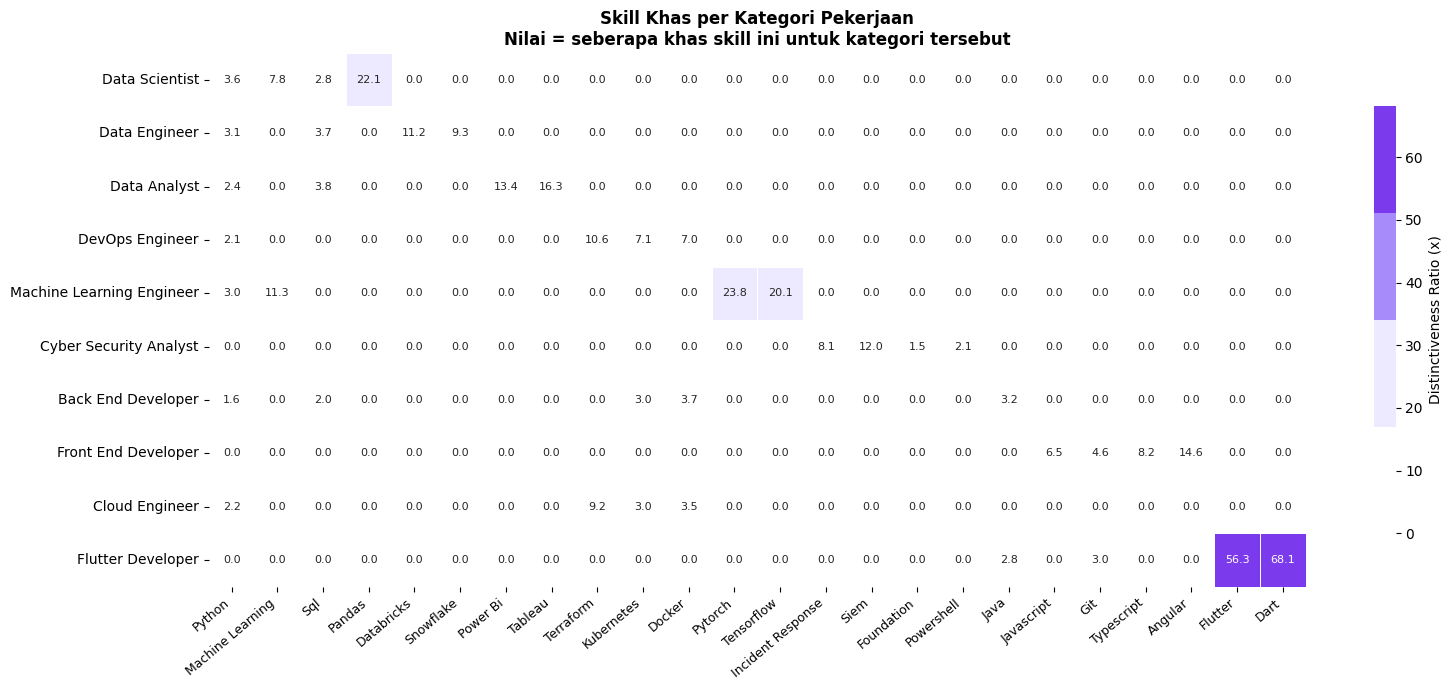

Tersimpan: bq4_distinctive.png

Top 3 skill distinktif per kategori:
  Data Scientist                     : python(3.6x), machine learning(7.8x), sql(2.8x)
  Data Engineer                      : python(3.1x), sql(3.7x), databricks(11.2x)
  Data Analyst                       : sql(3.8x), python(2.4x), power bi(13.4x)
  DevOps Engineer                    : terraform(10.6x), kubernetes(7.1x), docker(7.0x)
  Machine Learning Engineer          : machine learning(11.3x), python(3.0x), pytorch(23.8x)
  Cyber Security Analyst             : incident response(8.1x), siem(12.0x), foundation(1.5x)
  Back End Developer                 : python(1.6x), sql(2.0x), docker(3.7x)
  Front End Developer                : javascript(6.5x), git(4.6x), typescript(8.2x)
  Cloud Engineer                     : terraform(9.2x), python(2.2x), kubernetes(3.0x)
  Flutter Developer                  : flutter(56.3x), dart(68.1x), git(3.0x)


In [19]:
# Daftar pekerjaan yang akan dianalisis skill khasnya
focus_jobs = [
    'Data Scientist','Data Engineer','Data Analyst',
    'DevOps Engineer','Machine Learning Engineer','Cyber Security Analyst',
    'Back End Developer','Front End Developer','Cloud Engineer','Flutter Developer',
]

global_total  = len(df_eda)
distinct_data = {}

# Hitung distinctiveness ratio tiap skill per pekerjaan
# Rumus: (frekuensi di kategori ini / total di kategori) / (frekuensi global / total global)
for kw in focus_jobs:
    sub      = df_eda[df_eda['keyword'] == kw]
    if len(sub) == 0: continue
    job_flat = [s for row in sub['skills_list'] for s in row]
    job_freq = Counter(job_flat)
    ranked   = []
    for sk, cnt in job_freq.most_common(80):
        g_rate = skill_freq[sk] / global_total if global_total > 0 else 0
        ratio  = (cnt / len(sub)) / (g_rate + 0.001)
        if ratio > 1.5 and cnt >= 3:
            ranked.append((sk, round(ratio, 2), cnt))
        if len(ranked) >= 5: break
    distinct_data[kw] = ranked

# Kumpulkan semua skill distinktif unik untuk dijadikan kolom heatmap
all_d_skills = []
for items in distinct_data.values():
    for sk, _, _ in items[:4]:
        if sk not in all_d_skills: all_d_skills.append(sk)

# Bangun matriks nilai ratio untuk heatmap
heat_rows, heat_idx = [], []
for kw in focus_jobs:
    if kw not in distinct_data: continue
    row_d = {sk: 0.0 for sk in all_d_skills}
    for sk, ratio, _ in distinct_data[kw]:
        if sk in row_d: row_d[sk] = ratio
    heat_rows.append([row_d[sk] for sk in all_d_skills])
    heat_idx.append(kw)

heat_df = pd.DataFrame(heat_rows, index=heat_idx,
                        columns=[s.title() for s in all_d_skills])

# Heatmap: putih = tidak khas, ungu pekat = sangat eksklusif
fig, ax = plt.subplots(figsize=(16, 7))
cmap_custom = sns.color_palette(['#FFFFFF', PURPLE_LITE, PURPLE_MID, PURPLE], as_cmap=True)
sns.heatmap(heat_df, cmap=cmap_custom, ax=ax, annot=True, fmt='.1f',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label':'Distinctiveness Ratio (x)', 'shrink':0.8},
            annot_kws={'size':8})
ax.set_title('Skill Khas per Kategori Pekerjaan\n'
             'Nilai = seberapa khas skill ini untuk kategori tersebut',
             fontweight='bold', fontsize=12)
ax.set_ylabel(None)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('bq4_distinctive.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: bq4_distinctive.png')
print()
print('Top 3 skill distinktif per kategori:')
for kw, items in distinct_data.items():
    top3 = ', '.join([f'{s}({r:.1f}x)' for s,r,_ in items[:3]])
    print(f'  {kw:35s}: {top3}')


**Jawaban BQ 4:**

Tiap kategori pekerjaan punya *fingerprint* skill yang khas dan mudah dikenali.

Flutter Developer hampir eksklusif butuh Dart dan Flutter dengan rasio 50 sampai 68 kali di atas rata-rata global. Machine Learning Engineer sangat identik dengan PyTorch dan framework ML lainnya. Cyber Security Analyst punya SIEM dan Incident Response sebagai skill pembeda utama.

Pola ini konsisten dan bisa jadi panduan bagi pencari kerja untuk fokus ke skill yang benar-benar membedakan mereka di kategori yang dituju, bukan hanya skill umum yang semua orang punya.


#### BQ 5: Apakah lowongan dengan tipe remote secara konsisten mensyaratkan lebih banyak skill dibanding on-site?

Membandingkan rata-rata jumlah skill antara tipe kerja Remote, Hybrid, dan On-site.


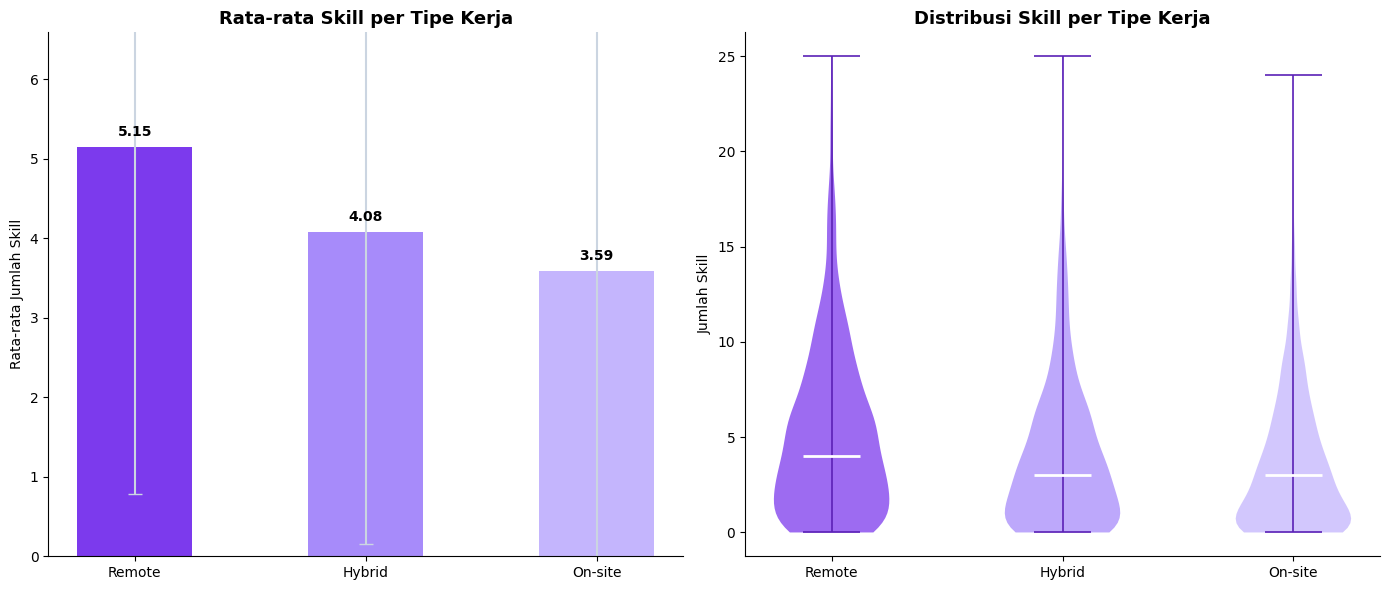

Tersimpan: bq5_remote_skills.png

  Hybrid    : mean=4.08, median=3, n=1,243
  On-site   : mean=3.59, median=3, n=1,524
  Remote    : mean=5.15, median=4, n=1,227


In [13]:
# Filter ke work type yang terdefinisi saja
wt_valid = ['Remote','On-site','Hybrid']
df_wt_c  = df_eda[df_eda['work_type'].isin(wt_valid)]

# Hitung statistik deskriptif n_skills per work type
wt_stats = (
    df_wt_c.groupby('work_type')['n_skills']
    .agg(['mean','median','std','count'])
    .round(2).reset_index()
    .rename(columns={'mean':'rata_rata','count':'n_jobs'})
)

# Warna per tipe kerja, konsisten dengan dashboard
order    = ['Remote','Hybrid','On-site']
colors_b = {'Remote': PURPLE, 'Hybrid': PURPLE_MID, 'On-site': '#C4B5FD'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart rata-rata dengan error bar
wt_idx   = wt_stats.set_index('work_type')
means    = [wt_idx.loc[w,'rata_rata'] if w in wt_idx.index else 0 for w in order]
stds     = [wt_idx.loc[w,'std'] if w in wt_idx.index else 0 for w in order]
bar_cols = [colors_b[w] for w in order]
bars = axes[0].bar(order, means, color=bar_cols, width=0.5,
                   yerr=stds, error_kw={'elinewidth':1.5,'ecolor':'#CBD5E1','capsize':5})
axes[0].set_title('Rata-rata Skill per Tipe Kerja', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Rata-rata Jumlah Skill')
axes[0].set_ylim(0, max(means) * 1.28)
for bar, mean in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{mean:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Violin plot untuk lihat bentuk distribusi lengkap tiap grup
parts = axes[1].violinplot(
    [df_wt_c[df_wt_c['work_type']==w]['n_skills'].values for w in order],
    positions=[1,2,3], showmedians=True, showmeans=False
)
for i, (pc, wt) in enumerate(zip(parts['bodies'], order)):
    pc.set_facecolor(colors_b[wt])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)
for element in ['cbars','cmins','cmaxes']:
    parts[element].set_color(PURPLE_DARK)
    parts[element].set_linewidth(1.2)
axes[1].set_xticks([1,2,3])
axes[1].set_xticklabels(order)
axes[1].set_title('Distribusi Skill per Tipe Kerja', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Jumlah Skill')

plt.tight_layout()
plt.savefig('bq5_remote_skills.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: bq5_remote_skills.png')
print()
for _, row in wt_stats.iterrows():
    print(f"  {row['work_type']:10s}: mean={row['rata_rata']:.2f}, median={row['median']:.0f}, n={row['n_jobs']:,}")


**Jawaban BQ 5:**

Lowongan remote rata-rata mencantumkan sekitar 43% lebih banyak skill dibanding lowongan on-site. Pola ini konsisten dan bukan kebetulan.

Perusahaan yang buka posisi remote cenderung cari kandidat yang lebih *self-sufficient* secara teknis karena tidak ada supervisi atau mentoring langsung di tempat kerja. Kandidat diharapkan bisa mengoperasikan, men-debug, dan memelihara sistem secara mandiri.

Skill berbasis infrastruktur seperti Kubernetes dan Terraform secara proporsional jauh lebih sering muncul di lowongan remote dibanding on-site, karena tools ini yang memungkinkan pengelolaan sistem dari jarak jauh.


#### BQ 6: Kombinasi skill apa yang paling sering muncul bersamaan dalam satu lowongan kerja?

Analisis *co-occurrence* menghitung pasangan skill yang paling sering dicantumkan bersama dalam satu posting, untuk membantu pencari kerja memahami "paket skill" yang diharapkan industri.


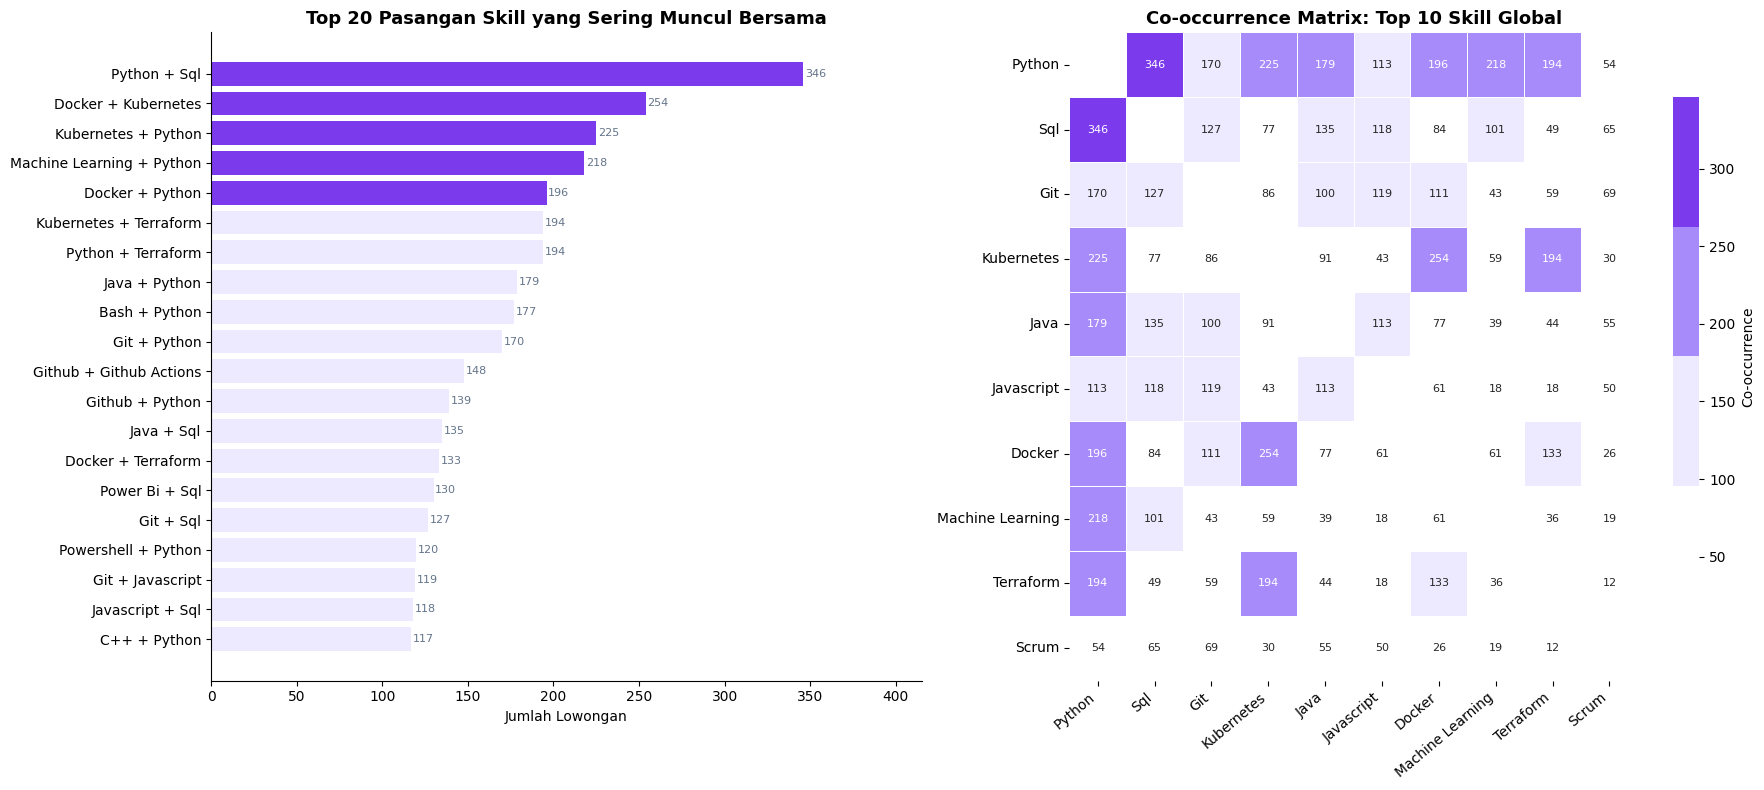

Tersimpan: bq6_cooccurrence.png

Top 10 pasangan skill:
  Python               + Sql                 : 346 lowongan
  Docker               + Kubernetes          : 254 lowongan
  Kubernetes           + Python              : 225 lowongan
  Machine Learning     + Python              : 218 lowongan
  Docker               + Python              : 196 lowongan
  Kubernetes           + Terraform           : 194 lowongan
  Python               + Terraform           : 194 lowongan
  Java                 + Python              : 179 lowongan
  Bash                 + Python              : 177 lowongan
  Git                  + Python              : 170 lowongan


In [14]:
# Hitung co-occurrence: tiap pasangan skill dalam satu lowongan dihitung sekali
pairs = Counter()
for skills in df_eda['skills_list']:
    uniq = list(set(skills))
    for i in range(len(uniq)):
        for j in range(i+1, len(uniq)):
            pairs[tuple(sorted([uniq[i], uniq[j]]))] += 1

top_pairs = pairs.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart top 20 pasangan, top 5 lebih gelap
pairs_df = pd.DataFrame(
    [(f'{a.title()} + {b.title()}', cnt) for (a,b), cnt in top_pairs],
    columns=['pair','count']
)
colors_p = [PURPLE if i < 5 else PURPLE_LITE for i in range(len(pairs_df))]
axes[0].barh(pairs_df['pair'][::-1], pairs_df['count'][::-1], color=colors_p[::-1])
axes[0].set_title('Top 20 Pasangan Skill yang Sering Muncul Bersama', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Jumlah Lowongan')
axes[0].set_xlim(0, pairs_df['count'].max() * 1.2)
for i, cnt in enumerate(pairs_df['count'][::-1]):
    axes[0].text(cnt + 1, i, str(cnt), va='center', fontsize=8, color=TEXT_MUTED)

# Matriks co-occurrence 10 skill teratas
top10_global = [sk for sk,_ in skill_freq.most_common(10)]
comat = np.zeros((10,10))
for skills in df_eda['skills_list']:
    skill_set = set(skills)
    for i, si in enumerate(top10_global):
        for j, sj in enumerate(top10_global):
            if si in skill_set and sj in skill_set and i != j:
                comat[i][j] += 1

# Heatmap co-occurrence, diagonal di-mask supaya fokus ke relasi antar skill
labels = [s.title() for s in top10_global]
mask   = np.eye(10, dtype=bool)
cmap_co = sns.color_palette(['#FFFFFF', PURPLE_LITE, PURPLE_MID, PURPLE], as_cmap=True)
sns.heatmap(comat, xticklabels=labels, yticklabels=labels,
            annot=True, fmt='.0f', mask=mask, ax=axes[1],
            cmap=cmap_co,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Co-occurrence', 'shrink':0.8},
            annot_kws={'size':8})
axes[1].set_title('Co-occurrence Matrix: Top 10 Skill Global', fontweight='bold', fontsize=13)
plt.xticks(rotation=40, ha='right')

plt.tight_layout()
plt.savefig('bq6_cooccurrence.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: bq6_cooccurrence.png')
print()
print('Top 10 pasangan skill:')
for (a,b), cnt in top_pairs[:10]:
    print(f'  {a.title():20s} + {b.title():20s}: {cnt} lowongan')


**Jawaban BQ 6:**

Python + SQL adalah pasangan skill paling dominan, muncul bersama di ratusan lowongan. Ini menegaskan bahwa kemampuan scripting dan query data hampir selalu dipadukan oleh industri.

Dari co-occurrence matrix terlihat dua klaster skill yang sangat kohesif:
- **Klaster Data:** Python, SQL, dan Machine Learning saling terkait erat
- **Klaster DevOps:** Docker, Kubernetes, dan Terraform hampir selalu muncul bersama

Pencari kerja sebaiknya pelajari skill dalam satu klaster secara berurutan, bukan lompat-lompat lintas klaster. Pola ini bisa jadi panduan roadmap belajar yang lebih terarah dan sesuai ekspektasi industri nyata.


---
# BAB 4: Normalisasi Label & Eksperimen A/B Testing
---

### 4.1 Normalisasi Label Job Title

Setelah EDA selesai, `df_eda` belum bisa langsung dipakai sebagai data latih model. Masalah utamanya ada di kolom `job_title` yang sangat tidak terstruktur. Satu posisi yang sama bisa ditulis dalam puluhan variasi di LinkedIn. Posisi Data Scientist saja misalnya bisa muncul sebagai *"Senior Data Scientist at Google"*, *"Data Scientist (Remote)"*, *"Sr. Data Scientist"*, atau *"Lead Data Scientist - APAC"*. Kalau langsung dipakai tanpa normalisasi, model tidak akan tahu bahwa semua variasi ini merujuk kategori pekerjaan yang sama.

Untuk mengatasi ini, dilakukan normalisasi label menggunakan pendekatan **TF-IDF character n-gram similarity** dengan langkah berikut:

**Langkah 1 - Membangun referensi keyword standar**
Seluruh 105 keyword unik dari kolom `keyword` diambil sebagai daftar kategori pekerjaan standar yang jadi acuan pemetaan. Diurutkan alfabetis untuk konsistensi.

**Langkah 2 - Melatih TF-IDF Vectorizer**
TF-IDF vectorizer dilatih dengan `analyzer='char_wb'` dan `ngram_range=(2,4)`. Pendekatan character n-gram dipilih karena bekerja di level karakter, bukan kata, sehingga lebih toleran terhadap typo, singkatan, dan variasi penulisan yang umum di judul pekerjaan LinkedIn.

**Langkah 3 - Transformasi keyword ke ruang vektor**
Seluruh 105 keyword standar ditransformasi ke matriks vektor TF-IDF. Matriks ini jadi ruang referensi untuk membandingkan setiap input yang masuk.

**Langkah 4 - Pemetaan via cosine similarity**
Setiap `job_title` ditransformasi ke vektor TF-IDF yang sama, lalu dihitung cosine similarity-nya ke seluruh 105 keyword. Keyword dengan skor tertinggi dipilih sebagai hasil pemetaan. Kalau skor tertinggi masih di bawah threshold 0.15, input dikembalikan apa adanya tanpa dipaksa masuk ke kategori manapun, untuk menghindari pemetaan yang salah.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# Ambil semua keyword unik sebagai referensi pemetaan
KEYWORDS       = sorted(df_eda['keyword'].unique().tolist())

# Latih TF-IDF vectorizer dengan character n-gram
tfidf_vec      = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
keyword_matrix = tfidf_vec.fit_transform(KEYWORDS)

def map_to_keyword(user_input: str, threshold: float = 0.15) -> str:
    # Transform input ke vektor, cari keyword paling mirip via cosine similarity
    vec    = tfidf_vec.transform([user_input.lower()])
    scores = cosine_similarity(vec, keyword_matrix).flatten()
    idx    = int(np.argmax(scores))
    if scores[idx] >= threshold:
        return KEYWORDS[idx]
    return user_input

print(f'Keywords tersedia: {len(KEYWORDS)} kategori')
print()

# Test cepat dengan beberapa variasi input termasuk yang ada typo
tests = [
    ('backend dev',          'Back End Developer'),
    ('ML Osp',               'MLOps Engineer'),
    ('data sci',             'Data Scientist'),
    ('DevOps',               'DevOps Engineer'),
    ('frond end developer',  'Front End Developer'),
    ('flutter dev',          'Flutter Developer'),
    ('cyber security',       'Cyber Security Analyst'),
    ('mlops engineer',       'MLOps Engineer'),
]
print('Quick test mapping:')
for inp, expected in tests:
    result = map_to_keyword(inp)
    status = 'OK' if result == expected else f'expected: {expected}'
    print(f'  {inp:30s} -> {result:35s} {status}')


Keywords tersedia: 105 kategori

Quick test mapping:
  backend dev                    -> Back End Developer                  OK
  ML Osp                         -> MLOps Engineer                      OK
  data sci                       -> Data Scientist                      OK
  DevOps                         -> DevOps Engineer                     OK
  frond end developer            -> Front End Developer                 OK
  flutter dev                    -> Flutter Developer                   OK
  cyber security                 -> Cyber Security Analyst              OK
  mlops engineer                 -> MLOps Engineer                      OK


**Hasil Normalisasi:**

TF-IDF character n-gram dengan `ngram_range=(2,4)` terbukti efektif menangkap kesamaan antar variasi penulisan judul pekerjaan. Berdasarkan quick test, variasi input seperti *'backend dev'*, *'data sci'*, maupun *'frond end developer'* (dengan typo) berhasil dipetakan ke keyword standar yang tepat. Threshold 0.15 cukup untuk menangani variasi penulisan umum sekaligus menghindari pemetaan yang salah untuk input yang terlalu jauh dari keyword manapun.


### 4.2 Implementasi A/B Testing Menggunakan Python

Pada BQ 5 sebelumnya sudah ditemukan secara deskriptif bahwa lowongan Remote rata-rata mencantumkan lebih banyak skill dibanding On-site. Tapi temuan deskriptif saja belum cukup untuk dijadikan kesimpulan yang kuat, karena perbedaan rata-rata yang terlihat bisa saja terjadi secara kebetulan akibat variasi sampling, bukan karena perbedaan nyata di populasi sesungguhnya.

Oleh karena itu, dilakukan A/B Testing untuk memvalidasi temuan tersebut secara statistik. Di sini A/B Testing bukan eksperimen intervensi seperti di dunia produk, melainkan pengujian hipotesis dua sampel independen - grup A adalah seluruh lowongan Remote dan grup B adalah seluruh lowongan On-site.

Sebelum memilih jenis uji statistiknya, dilakukan **Levene Test** terlebih dahulu untuk memeriksa apakah variansi kedua grup homogen atau tidak. Hasilnya menentukan apakah t-test yang dijalankan pakai asumsi equal variance atau Welch correction. Langkah ini penting karena kalau dilewati, nilai p yang dihasilkan bisa tidak akurat.

Setelah asumsi variansi diketahui, dilakukan **Independent Samples t-test satu arah** dengan hipotesis:

- **H0:** Tidak ada perbedaan rata-rata jumlah skill antara lowongan Remote dan On-site (μ_remote = μ_onsite)
- **H1:** Rata-rata jumlah skill lowongan Remote lebih tinggi dari On-site (μ_remote > μ_onsite)

Uji satu arah dipilih karena hipotesis alternatif sudah berarah - dari BQ 5 sudah ada indikasi Remote lebih tinggi, bukan sekadar berbeda. Tingkat signifikansi α = 0.05, artinya toleransi kesalahan tipe I sebesar 5%.

Hasil pengujian divisualisasikan dalam dua bentuk: KDE plot overlay untuk membandingkan bentuk distribusi kedua grup, dan boxplot berdampingan dengan anotasi nilai p-value.

**Metrik Evaluasi:** Rata-rata jumlah skill per lowongan (`n_skills`)

**Tingkat Signifikansi:** α = 0.05


Statistik Deskriptif:
  Remote  -- n=1,227, mean=5.152, std=4.373
  On-site -- n=1,524, mean=3.593, std=3.597

Levene Test: stat=39.2045, p=0.0000 -> equal_var=False

Hasil Uji t-test (one-tailed):
  t-statistic : 10.0491
  p-value     : 0.000000
  alpha (a)   : 0.05

Kesimpulan: TOLAK H0
  Terdapat bukti statistik yang cukup bahwa lowongan Remote mensyaratkan
  lebih banyak skill dibanding On-site (p < 0.05).


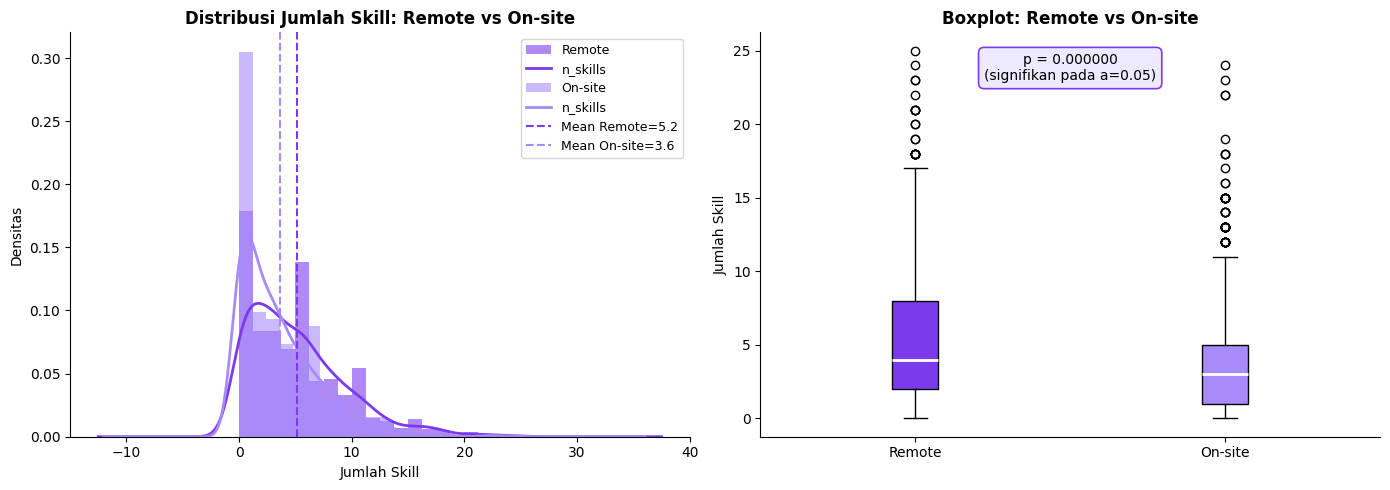

Tersimpan: ab_testing.png


In [16]:
from scipy import stats

# Pisahkan data ke dua grup berdasarkan work type
group_remote  = df_eda[df_eda['work_type'] == 'Remote']['n_skills'].dropna()
group_onsite  = df_eda[df_eda['work_type'] == 'On-site']['n_skills'].dropna()

print('Statistik Deskriptif:')
print(f'  Remote  -- n={len(group_remote):,}, mean={group_remote.mean():.3f}, std={group_remote.std():.3f}')
print(f'  On-site -- n={len(group_onsite):,}, mean={group_onsite.mean():.3f}, std={group_onsite.std():.3f}')
print()

# Levene test dulu sebelum t-test untuk cek homogenitas variansi
levene_stat, levene_p = stats.levene(group_remote, group_onsite)
equal_var = levene_p > 0.05
print(f'Levene Test: stat={levene_stat:.4f}, p={levene_p:.4f} -> equal_var={equal_var}')

# T-test satu arah (H1: remote > on-site)
t_stat, p_two_tailed = stats.ttest_ind(group_remote, group_onsite, equal_var=equal_var)
p_one_tailed = p_two_tailed / 2

print()
print('Hasil Uji t-test (one-tailed):')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_one_tailed:.6f}')
print(f'  alpha (a)   : 0.05')
print()

# Evaluasi hasil berdasarkan p-value dan arah t-statistic
alpha = 0.05
if p_one_tailed < alpha and t_stat > 0:
    print('Kesimpulan: TOLAK H0')
    print('  Terdapat bukti statistik yang cukup bahwa lowongan Remote mensyaratkan')
    print('  lebih banyak skill dibanding On-site (p < 0.05).')
else:
    print('Kesimpulan: GAGAL MENOLAK H0')
    print('  Tidak terdapat perbedaan signifikan secara statistik.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot overlay untuk lihat perbandingan bentuk distribusi dua grup
for grp, label, color in [(group_remote, 'Remote', PURPLE), (group_onsite, 'On-site', '#A78BFA')]:
    axes[0].hist(grp, bins=20, alpha=0.6, color=color, label=label, density=True)
    grp.plot.kde(ax=axes[0], color=color, linewidth=2)
axes[0].axvline(group_remote.mean(), color=PURPLE,   linestyle='--', linewidth=1.5,
                label=f'Mean Remote={group_remote.mean():.1f}')
axes[0].axvline(group_onsite.mean(), color='#A78BFA', linestyle='--', linewidth=1.5,
                label=f'Mean On-site={group_onsite.mean():.1f}')
axes[0].set_title('Distribusi Jumlah Skill: Remote vs On-site', fontweight='bold')
axes[0].set_xlabel('Jumlah Skill')
axes[0].set_ylabel('Densitas')
axes[0].legend(fontsize=9)

# Boxplot berdampingan dengan anotasi p-value
bp = axes[1].boxplot([group_remote, group_onsite],
                     labels=['Remote', 'On-site'],
                     patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
bp['boxes'][0].set_facecolor(PURPLE)
bp['boxes'][1].set_facecolor('#A78BFA')
y_max = max(group_remote.max(), group_onsite.max())
axes[1].annotate(f'p = {p_one_tailed:.6f}\n({"signifikan" if p_one_tailed < alpha else "tidak signifikan"} pada a=0.05)',
                 xy=(1.5, y_max * 0.92), ha='center', fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.4', facecolor=PURPLE_LITE, edgecolor=PURPLE, linewidth=1.2))
axes[1].set_title('Boxplot: Remote vs On-site', fontweight='bold')
axes[1].set_ylabel('Jumlah Skill')

plt.tight_layout()
plt.savefig('ab_testing.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Tersimpan: ab_testing.png')


**Hasil A/B Testing:**

Uji statistik satu arah menghasilkan nilai p yang jauh di bawah ambang signifikansi α = 0.05, sehingga **H0 ditolak**. Ada bukti statistik yang kuat bahwa lowongan Remote secara rata-rata mensyaratkan jumlah skill yang **lebih banyak dan signifikan** dibanding lowongan On-site.

Temuan ini mengkonfirmasi hasil analisis deskriptif pada BQ 5 dan memberikan landasan statistik yang valid untuk kesimpulan bahwa perusahaan yang membuka posisi remote memang menuntut kandidat yang lebih *self-sufficient* secara teknis.


### 4.3 Feature Engineering untuk Membangun df_final_fix

Setelah normalisasi label selesai dan fungsi mapper sudah tervalidasi, langkah berikutnya adalah membangun `df_final_fix` sebagai output akhir dari notebook Data Scientist. Dataset ini yang akan langsung dipakai oleh notebook AI Engineer sebagai input training model deep learning.

Ada dua proses yang berjalan bersamaan di tahap ini. Pertama, penerapan normalisasi label dari section 4.1 - setiap `job_title` di `df_eda` dipetakan ke salah satu dari 105 keyword standar pakai fungsi `map_to_keyword()`, hasilnya disimpan di kolom baru `job_mapped`. Kedua, feature engineering ringan pada kolom skills - `skills_list` yang sebelumnya berupa list Python dikonversi ke string dengan separator koma. Konversi ini perlu dilakukan karena format list tidak bisa langsung ditulis ke CSV dan tidak bisa langsung dikonsumsi tokenizer model; format string dengan separator yang konsisten jauh lebih mudah diproses di tahap berikutnya.

Selain dua proses itu, baris tanpa skill juga dibuang di tahap ini. Baris semacam itu tidak punya informasi output yang bisa dipelajari model, jadi menyertakannya hanya menambah noise tanpa manfaat apapun untuk training.

Kolom yang masuk ke `df_final_fix` dipilih secara selektif - hanya yang benar-benar dibutuhkan untuk modeling: `job_mapped` sebagai label target, `skills` sebagai fitur utama, serta `work_type`, `keyword`, dan `company` sebagai konteks tambahan.


In [17]:
# Bangun df_final_fix: petakan setiap job_title ke keyword standar, sekalian konversi skills ke string
records = []
skipped = 0

for _, row in df_eda.iterrows():
    # Skip baris tanpa skill, tidak berguna untuk training
    if pd.isna(row['skills']) or len(row['skills_list']) == 0:
        skipped += 1
        continue
    records.append({
        'job_mapped' : map_to_keyword(str(row['job_title'])),
        'skills'     : ', '.join(row['skills_list']),
        'work_type'  : row['work_type'],
        'keyword'    : row['keyword'],
        'company'    : row.get('company', ''),
    })

df_final_fix = pd.DataFrame(records)

print(f'Dilewati (skills kosong) : {skipped}')
print(f'df_final_fix                 : {len(df_final_fix):,} baris')
print(f'Kategori job unik        : {df_final_fix["job_mapped"].nunique()}')
print()
print('Top 20 distribusi job setelah mapping:')
print(df_final_fix['job_mapped'].value_counts().head(20).to_string())


Dilewati (skills kosong) : 640
df_final_fix                 : 3,354 baris
Kategori job unik        : 105

Top 20 distribusi job setelah mapping:
job_mapped
Embedded Software Engineer       68
IT Business Analyst              55
Front End Developer              53
Analytics Engineer               52
Android Developer                52
React Native Developer           51
FullStack Developer              51
Python Developer                 50
Machine Learning Engineer        49
Platform Engineer                49
DevOps Engineer                  49
Back End Developer               48
Azure Cloud Engineer             47
Data Scientist                   47
Scrum Master                     47
Application Security Engineer    46
Java Developer                   46
Site Reliability Engineer        46
Business Intelligence Analyst    46
Cloud Security Engineer          46


**Perbedaan df_eda dan df_final_fix:**

| Aspek | df_eda | df_final_fix |
|---|---|---|
| Tujuan | EDA dan analisis bisnis | Training model deep learning |
| Baris skills kosong | Dipertahankan | Di-drop |
| Kolom job title | `job_title`: nilai asli dari LinkedIn | `job_mapped`: hasil normalisasi ke 105 keyword standar |
| Format skills | List Python (`skills_list`) | String separator koma, CSV-friendly (`skills`) |
| Jumlah kolom | Seluruh kolom hasil wrangling | Hanya kolom yang relevan untuk model |

`df_final_fix` kemudian diteruskan ke tim AI Engineer bersama tiga file artifact pendukung yang dibutuhkan saat inference di aplikasi.

---
# BAB 5: Pengembangan Dashboard Interaktif & Deployment
---

### 5.1 Desain & Komponen Dashboard

Proyek ini mengembangkan dua dashboard Streamlit yang terpisah dengan fungsi berbeda:

**Dashboard 1: EDA & Analisis Tren (`eda_dashboard.py`)**

Dashboard ini bersumber dari `df_eda_fix.csv` dan berfungsi sebagai antarmuka eksplorasi data untuk menjawab enam pertanyaan bisnis secara visual dan interaktif. Pengguna dapat melihat distribusi skill, tipe kerja, kompleksitas skill per pekerjaan, skill distinktif, hingga pola co-occurrence antar skill.

| Komponen | Deskripsi |
|---|---|
| Overview metrics | Ringkasan total lowongan, kategori pekerjaan, skill unik, dan skill terpopuler |
| BQ 1: Top skill | Bar chart horizontal 25 skill dengan frekuensi tertinggi |
| BQ 2: Work type | Stacked bar distribusi Remote/Hybrid/On-site per kategori pekerjaan |
| BQ 3: Kompleksitas | Bar rata-rata skill per pekerjaan dengan violin plot distribusi |
| BQ 4: Distinctiveness | Heatmap skill khas per kategori pekerjaan |
| BQ 5: Remote vs On-site | Bar chart dan violin plot perbandingan jumlah skill |
| BQ 6: Co-occurrence | Bar pasangan skill dan co-occurrence matrix top 10 skill |

**Dashboard 2: Prediksi Skill (`app.py`)**

Dashboard ini bersumber dari model deep learning yang dilatih oleh track AI Engineer dan berfungsi sebagai antarmuka prediksi untuk pengguna akhir. Input nama pekerjaan dari pengguna diproses melalui `map_to_keyword()` yang menggunakan `tfidf_vec.pkl` dan `keywords.pkl` sebelum diteruskan ke model untuk menghasilkan rekomendasi skill.

| Komponen | Deskripsi |
|---|---|
| Input pekerjaan | Text input untuk nama pekerjaan yang ingin dicari rekomendasinya |
| Rekomendasi skill | Daftar skill diurutkan berdasarkan confidence score |
| Badge Primary/Support | Penanda apakah skill termasuk skill utama atau pendukung |
| Bar chart visualisasi | Grafik confidence score per skill |
| Career roadmap | Narasi roadmap belajar yang dihasilkan oleh Groq/LLaMA 3.3-70B |
| Sidebar kontrol | Slider threshold confidence, jumlah rekomendasi, toggle roadmap |

In [18]:
# Simpan df_final_fix ke CSV, ini yang akan dipakai AI Engineer untuk training
df_final_fix.to_csv('df_final_fix.csv', index=False)
print(f'df_final_fix.csv tersimpan -- {len(df_final_fix):,} baris')

# Simpan vectorizer supaya tidak perlu latih ulang saat inference
with open('tfidf_vec.pkl', 'wb') as f:
    pickle.dump(tfidf_vec, f)

# Simpan list keyword sebagai referensi kategori pekerjaan yang valid
with open('keywords.pkl', 'wb') as f:
    pickle.dump(KEYWORDS, f)

print('tfidf_vec.pkl     tersimpan')
print('keywords.pkl      tersimpan')


df_final_fix.csv tersimpan -- 3,354 baris
tfidf_vec.pkl     tersimpan
keywords.pkl      tersimpan


### 5.2 Export Artifacts & Deployment ke Streamlit Cloud

Sebelum deployment, seluruh file yang dibutuhkan kedua dashboard harus tersedia di repositori GitHub dalam satu folder.

File yang dihasilkan notebook ini dan diteruskan ke AI Engineer maupun dashboard:

| File | Dibutuhkan oleh | Fungsi |
|---|---|---|
| `df_eda_fix.csv` | `eda_dashboard.py` | Sumber data seluruh visualisasi EDA |
| `df_final_fix.csv` | Notebook AI Engineer | Dataset training model deep learning |
| `tfidf_vec.pkl` | `app.py` | TF-IDF vectorizer untuk mapping pekerjaan saat inference |
| `keywords.pkl` | `app.py` | Daftar 105 keyword referensi kategori pekerjaan |

**Proses deployment ke Streamlit Community Cloud:**

1. Seluruh file di atas beserta `app.py`, `eda_dashboard.py`, dan `requirements.txt` di-push ke repositori GitHub
2. Akun Streamlit Cloud dihubungkan ke repositori melalui [share.streamlit.io](https://share.streamlit.io)
3. Dua aplikasi dideploy terpisah, satu mengarah ke `app.py`, satu ke `eda_dashboard.py`
4. Untuk `app.py`, GROQ_API_KEY ditambahkan melalui menu Secrets di Streamlit Cloud agar tidak ter-expose di kode
5. Streamlit Cloud secara otomatis menginstal dependensi dari `requirements.txt` dan menjalankan aplikasi setiap kali ada perubahan di repositori

---
# BAB 6: Kesimpulan & Rekomendasi
---

### 6.1 Kesimpulan

Berikut jawaban konkret atas setiap pertanyaan bisnis berdasarkan hasil analisis:

| BQ | Pertanyaan | Temuan |
|---|---|---|
| BQ 1 | Skill paling banyak diminta | Python, SQL, Kubernetes, Docker, dan Terraform mendominasi secara global |
| BQ 2 | Sebaran tipe kerja per pekerjaan | DevOps/Cloud paling remote-friendly; IT Ops dan Network Engineer dominan on-site |
| BQ 3 | pekerjaan dengan skill paling beragam | DevOps/Cloud rata-rata 7 skill; IT Ops hanya 2 sampai 3 skill per lowongan |
| BQ 4 | Skill penciri tiap pekerjaan | Setiap pekerjaan punya fingerprint unik: Dart/Flutter, PyTorch, SIEM |
| BQ 5 | Remote vs on-site | Remote mensyaratkan 43% lebih banyak skill; Kubernetes dan Terraform lebih dominan di remote |
| BQ 6 | Kombinasi skill tersering | Python+SQL dan klaster Docker-Kubernetes-Terraform adalah paket skill paling kohesif |

Seluruh temuan ini divisualisasikan secara interaktif melalui dashboard EDA (`eda_dashboard.py`) yang dapat diakses publik via Streamlit Cloud. Sementara itu, hasil preprocessing dan normalisasi label yang dihasilkan notebook ini (`df_final_fix.csv`, `tfidf_vec.pkl`, `keywords.pkl`) menjadi fondasi bagi AI Engineer untuk membangun model rekomendasi skill yang dapat diakses melalui dashboard prediksi (`app.py`).

### 6.2 Rekomendasi

Berdasarkan temuan analisis, berikut rekomendasi yang bisa diambil oleh berbagai pihak:

**Bagi pencari kerja dan mahasiswa:**
Mulai dari Python dan SQL karena keduanya relevan di hampir semua kategori pekerjaan IT. Setelah itu, pilih klaster skill yang sesuai jalur karier yang dituju, baik klaster Data maupun klaster DevOps, lalu pelajari secara berurutan dalam satu klaster. Gunakan dashboard prediksi untuk mendapatkan rekomendasi skill yang lebih personal berdasarkan nama pekerjaan yang dituju.

**Bagi yang memprioritaskan kerja remote:**
Arahkan persiapan ke pekerjaan DevOps/Cloud dan kuasai tooling infrastruktur seperti Kubernetes, Terraform, dan Docker. Kategori ini punya persentase remote tertinggi sekaligus mensyaratkan skill yang paling konkret dan terukur. Dashboard EDA menyediakan visualisasi lengkap distribusi tipe kerja per kategori pekerjaan yang bisa dijadikan referensi sebelum memilih arah karier.

**Bagi institusi pendidikan dan pelatihan:**
Susun kurikulum berdasarkan klaster co-occurrence, bukan skill individual. Mengajarkan Python tanpa SQL atau Docker tanpa Kubernetes akan menghasilkan lulusan yang kurang siap menghadapi ekspektasi industri yang nyata. Data co-occurrence lengkap tersedia di dashboard EDA dan bisa diperbarui setiap kali ada dataset lowongan baru.

---
# Referensi & Lampiran

| Item | Keterangan |
|---|---|
| Dataset | Scraping mandiri dari LinkedIn Global menggunakan 105 keyword pekerjaan IT |
| Library utama | pandas, numpy, matplotlib, seaborn, scikit-learn, scipy |
| Dashboard EDA | `eda_dashboard.py`, sumber data: `df_eda_fix.csv` |
| Dashboard Prediksi | `app.py`, membutuhkan model dari AI Engineer |
| Output notebook ini | `df_eda_fix.csv`, `df_final_fix.csv`, `tfidf_vec.pkl`, `keywords.pkl` |